# **CAR PRICE PREDICTION MODEL(MULTIPLE LINEAR REGRESSION)**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection  import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.preprocessing import StandardScaler
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('car data.csv')

In [3]:
df.sample(2)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
184,Bajaj Pulsar 150,2008,0.25,0.75,26000,Petrol,Individual,Manual,1
75,etios g,2015,3.95,6.80,36000,Petrol,Dealer,Manual,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [5]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [6]:
df.drop_duplicates(keep='first',inplace=True)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe().round(1)

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,299.0,299.0,299.0,299.0,299.0
mean,2013.6,4.6,7.5,36916.8,0.0
std,2.9,5.0,8.6,39015.2,0.2
min,2003.0,0.1,0.3,500.0,0.0
25%,2012.0,0.8,1.2,15000.0,0.0
50%,2014.0,3.5,6.1,32000.0,0.0
75%,2016.0,6.0,9.8,48883.5,0.0
max,2018.0,35.0,92.6,500000.0,3.0


In [9]:
df['Fuel_Type'].value_counts()

Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

In [10]:
df['Seller_Type'].value_counts()

Seller_Type
Dealer        193
Individual    106
Name: count, dtype: int64

In [11]:
df['Transmission'].value_counts()

Transmission
Manual       260
Automatic     39
Name: count, dtype: int64

In [12]:
df['Owner'].value_counts()

Owner
0    288
1     10
3      1
Name: count, dtype: int64

Text(0, 0.5, 'selling price')

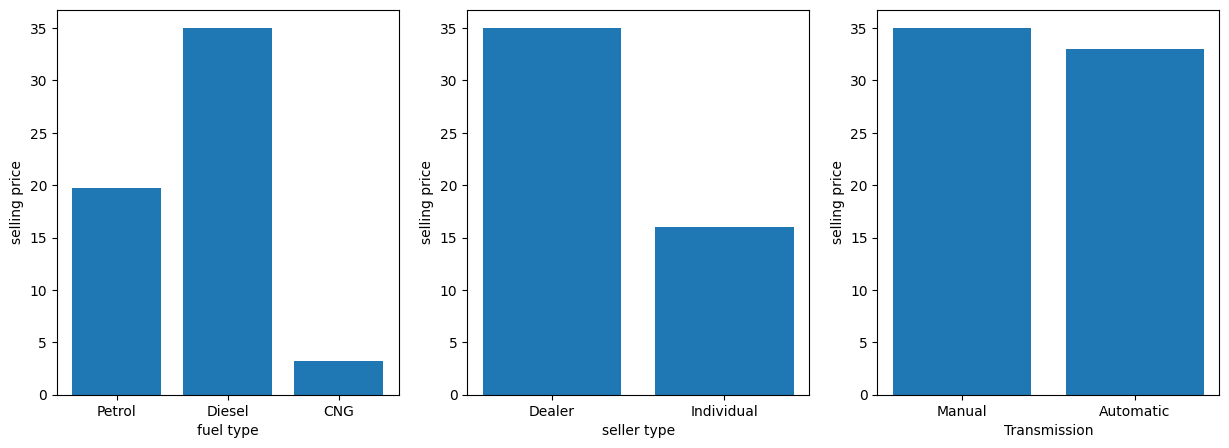

In [13]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.bar(df['Fuel_Type'],df['Selling_Price'])
plt.xlabel("fuel type")
plt.ylabel('selling price')

plt.subplot(1,3,2)
plt.bar(df['Seller_Type'],df['Selling_Price'])
plt.xlabel("seller type")
plt.ylabel('selling price')

plt.subplot(1,3,3)
plt.bar(df['Transmission'],df['Selling_Price'])
plt.xlabel("Transmission")
plt.ylabel('selling price')


<Axes: xlabel='Seller_Type', ylabel='Selling_Price'>

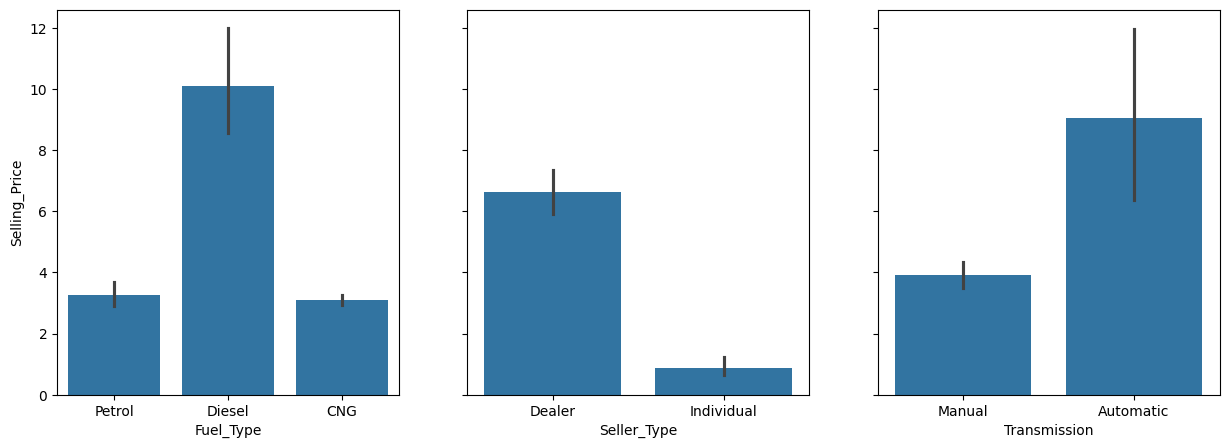

In [14]:

fig,axes=plt.subplots(1,3,figsize=(15,5),sharey=True)
sns.barplot(x=df['Fuel_Type'],y=df['Selling_Price'],ax=axes[0])
sns.barplot(x=df['Transmission'],y=df['Selling_Price'],ax=axes[2])
sns.barplot(x=df['Seller_Type'],y=df['Selling_Price'],ax=axes[1])

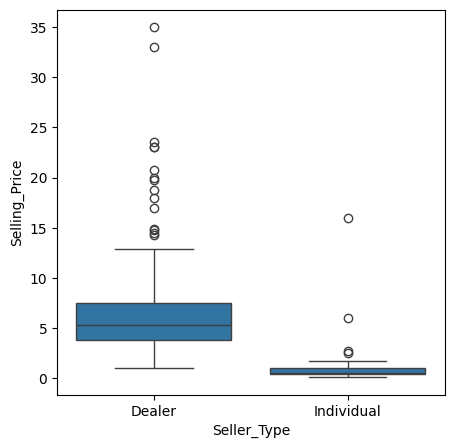

In [15]:
plt.figure(figsize=(5,5))
sns.boxplot(data=df,x='Seller_Type',   y='Selling_Price')
plt.show()

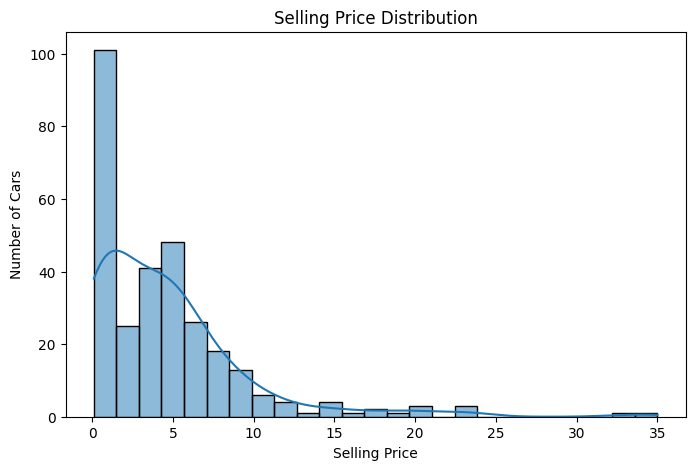

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Selling_Price', bins=25, kde=True)
plt.title('Selling Price Distribution')
plt.xlabel('Selling Price')
plt.ylabel('Number of Cars')
plt.show()

In [17]:
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return df[(df[col] >= lower) & (df[col] <= upper)]

df = remove_outliers(df, "Selling_Price")

In [18]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,283.000000,283.000000,283.000000,283.000000,283.000000
mean,2013.544170,3.696749,6.174841,36415.908127,0.045936
std,2.918635,3.046136,5.105825,38996.548461,0.255457
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.750000,1.020000,15000.500000,0.000000
50%,2014.000000,3.250000,5.870000,32000.000000,0.000000
75%,2016.000000,5.500000,9.400000,48383.500000,0.000000
max,2018.000000,12.900000,23.730000,500000.000000,3.000000


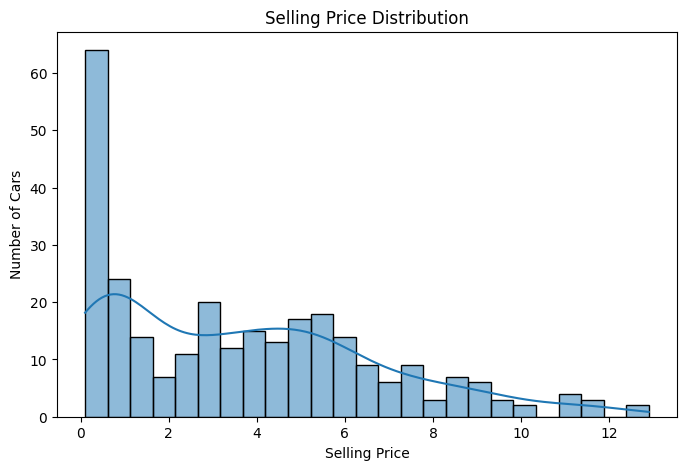

In [19]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Selling_Price', bins=25, kde=True)
plt.title('Selling Price Distribution')
plt.xlabel('Selling Price')
plt.ylabel('Number of Cars')
plt.show()

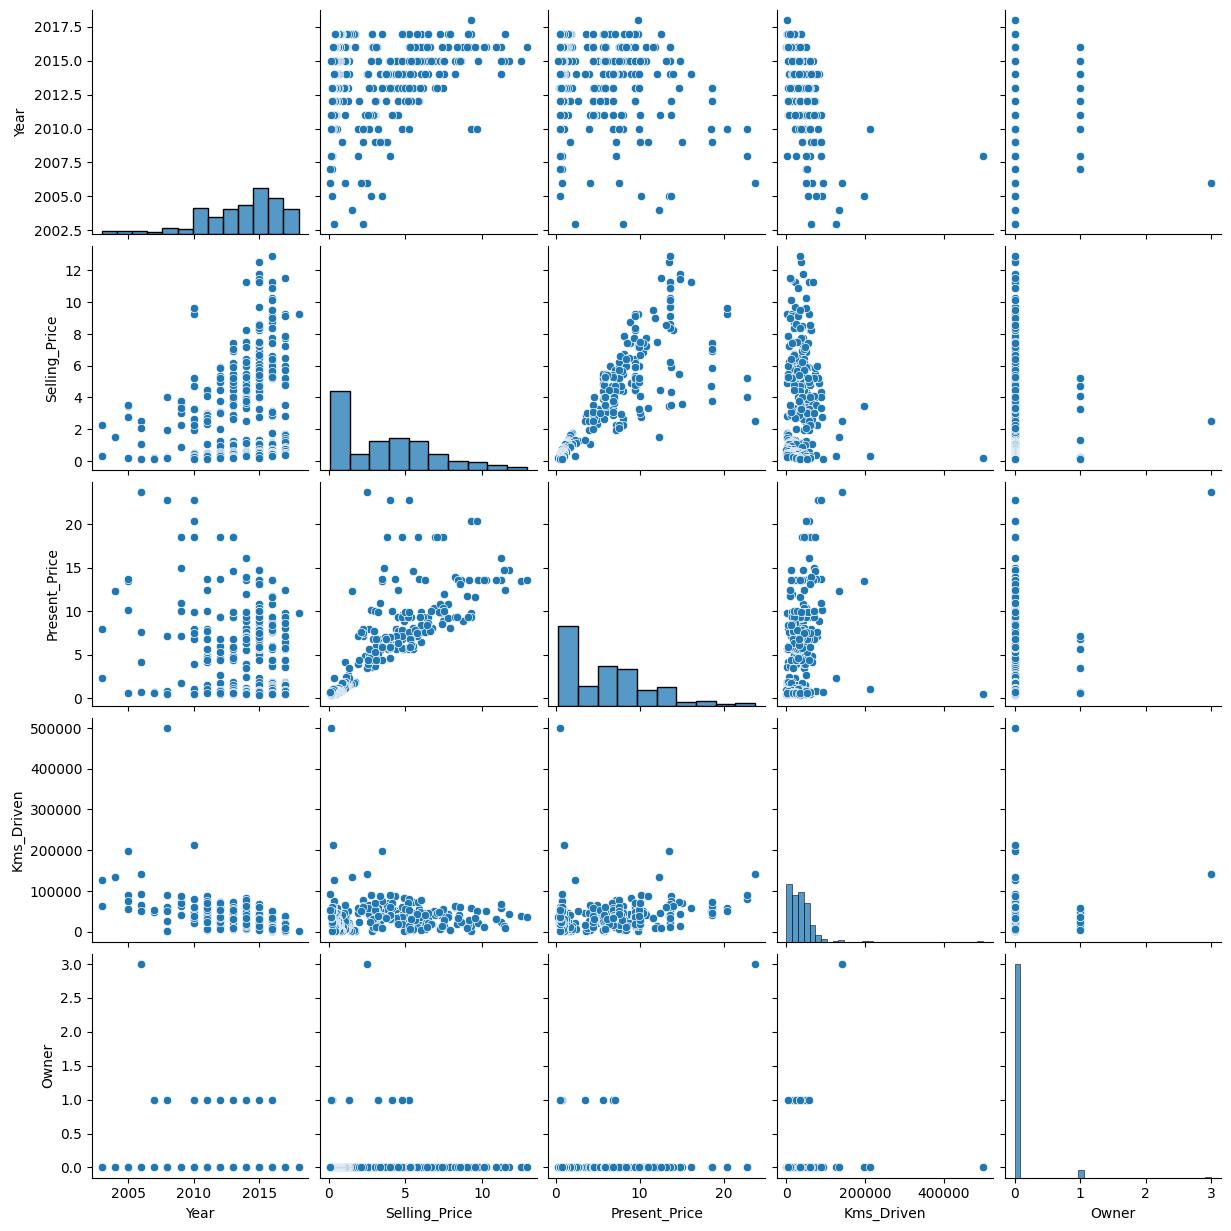

In [20]:
sns.pairplot(df)

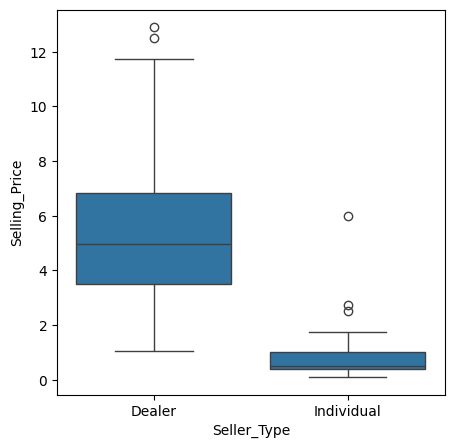

In [21]:
plt.figure(figsize=(5,5))
sns.boxplot(data=df,x='Seller_Type',   y='Selling_Price')
plt.show()

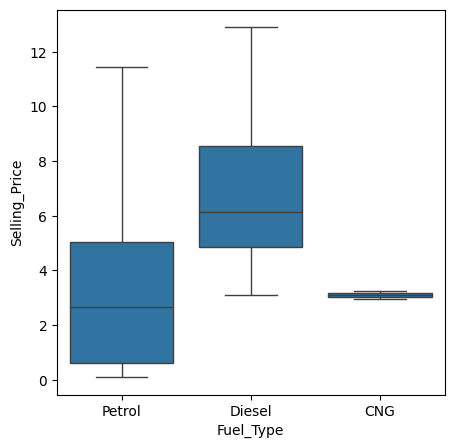

In [22]:
plt.figure(figsize=(5,5))
sns.boxplot(data=df,x='Fuel_Type',   y='Selling_Price')
plt.show()

In [23]:
df.groupby('Fuel_Type').get_group('Petrol').describe()


,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,236.000000,236.000000,236.000000,236.000000,236.000000
mean,2013.500000,3.089576,5.388856,33820.830508,0.050847
std,3.040857,2.730117,5.027179,40481.052180,0.272028
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.600000,0.925000,14000.000000,0.000000
50%,2014.000000,2.650000,4.430000,26000.000000,0.000000
75%,2016.000000,5.027500,7.877500,44656.500000,0.000000
max,2017.000000,11.450000,23.730000,500000.000000,3.000000


In [24]:
df.groupby('Seller_Type').get_group('Dealer').describe()



,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,178.000000,178.000000,178.000000,178.000000,178.000000
mean,2013.584270,5.448652,9.015449,39833.533708,0.022472
std,2.707216,2.485100,4.001761,24349.553258,0.148631
min,2003.000000,1.050000,2.690000,2071.000000,0.000000
25%,2012.000000,3.502500,5.972500,22930.500000,0.000000
50%,2014.000000,4.975000,7.980000,39242.500000,0.000000
75%,2015.000000,6.825000,10.380000,51958.750000,0.000000
max,2018.000000,12.900000,22.830000,197176.000000,1.000000


In [25]:
df['Fuel_Type'].unique()

<StringArray>
['Petrol', 'Diesel', 'CNG']
Length: 3, dtype: str

In [26]:
df.replace({'Fuel_Type':{'Petrol':0, 'Diesel':1, 'CNG':2}},inplace=True)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,1,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,0,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,0,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,1,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,1,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,0,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,0,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,1,Dealer,Manual,0


In [27]:
df=pd.get_dummies(df,columns=['Seller_Type','Transmission'],drop_first=True)

In [28]:
df.sample(5)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Owner,Seller_Type_Individual,Transmission_Manual
173,Activa 4g,2017,0.40,0.51,1300,0,0,True,False
30,ritz,2012,3.10,5.98,51439,1,0,False,True
165,Activa 3g,2016,0.45,0.54,500,0,0,True,False
61,etios cross,2015,4.50,7.70,40588,0,0,False,True
264,amaze,2015,4.00,7.00,40026,0,0,False,True


In [29]:
df.drop(columns='Car_Name',inplace=True)

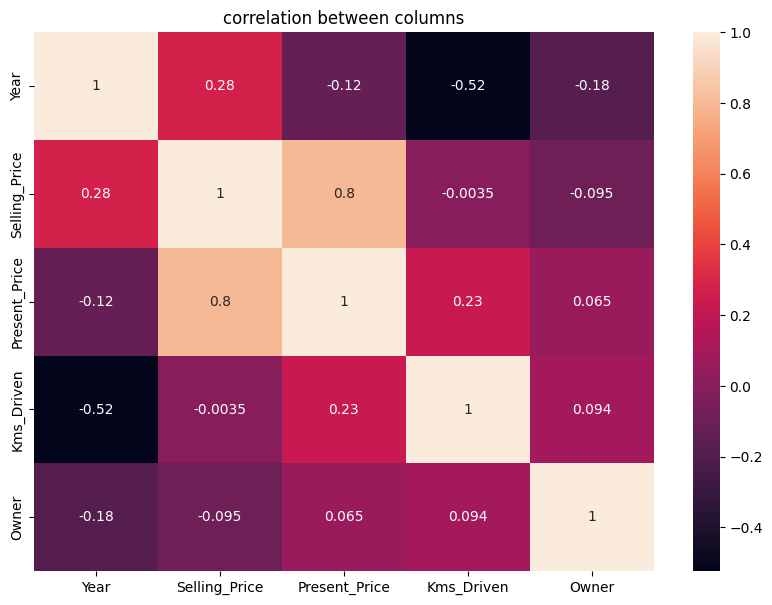

In [30]:
plt.figure(figsize=(10,7))
corr=df[df.select_dtypes(include='number').columns].corr()
sns.heatmap(corr,annot=True)
plt.title('correlation between columns')
plt.show()

<Axes: title={'center': 'correlation between present price and selling price'}, xlabel='Present_Price', ylabel='Selling_Price'>

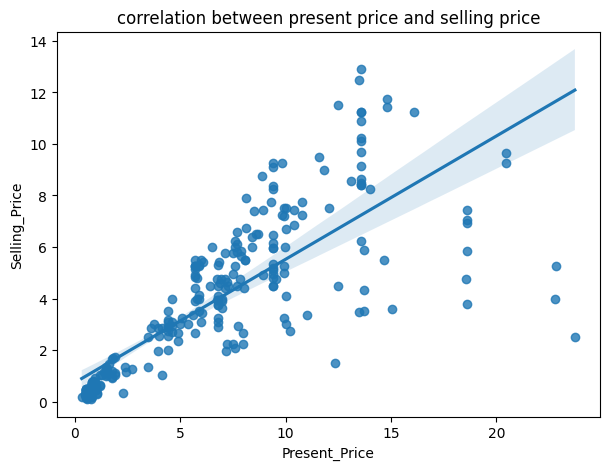

In [31]:
plt.figure(figsize=(7,5))
plt.title("correlation between present price and selling price")
sns.regplot(x='Present_Price',y='Selling_Price',data=df)

In [32]:
X=df.drop(columns='Selling_Price')
y=df['Selling_Price']

In [33]:
print(X.shape,' ',y.shape)

(283, 7)   (283,)


In [34]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(len(X),' ',len(X_train),' ',len(X_test))

283   226   57


In [35]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
print(X_train.mean())
print(X_train.std())

-1.369883276907905e-15
1.0


In [36]:
model=LinearRegression()
model.fit(X_train,y_train)
pred=model.predict(X_test)

In [37]:
print(y_test.values)
pred = np.clip(pred, 0,24.0)
print(pred.round(2))

[ 7.45  4.    0.48  2.7   3.8  10.11  5.25  0.35  5.5   0.25  1.05  8.99
  0.4   4.    9.25  3.9   8.35  0.12  5.95  5.5   0.75  4.5   4.75  5.5
  4.75  1.15  3.51  0.35  5.75  0.9   6.6   3.1   0.2   2.65  5.85  5.11
  1.5   1.75  3.5   0.6   2.35  2.5   3.    0.45  3.45  6.45  5.35  3.
  1.2   2.55  0.25  0.2   1.2   6.75  0.6   8.25  0.45]
[6.62 4.94 1.12 2.64 7.46 7.88 4.51 1.28 5.94 0.   0.75 7.18 1.6  4.47
 8.01 4.67 7.15 0.   5.89 5.94 1.45 6.66 6.2  4.44 5.5  1.72 4.17 0.
 5.07 1.85 5.56 2.98 0.   3.42 8.48 5.14 3.21 1.88 3.84 0.09 2.75 3.21
 2.79 0.77 3.88 5.54 5.79 4.07 1.72 2.56 0.   0.   1.83 5.39 1.46 8.27
 1.28]


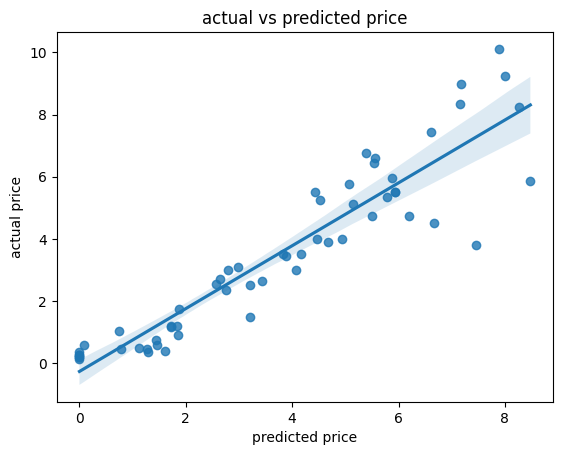

In [38]:
sns.regplot(x=pred,y=y_test)
plt.xlabel('predicted price')
plt.ylabel('actual price')
plt.title("actual vs predicted price")
plt.show()


In [39]:
print('MAE',mean_absolute_error(pred,y_test))
print('MSE',np.sqrt(mean_squared_error(pred,y_test)))
print('R2',r2_score(pred,y_test))
print("Slope:", model.coef_)
print("Intercept:", model.intercept_)
print(X.columns)

MAE 0.7772282966575698
MSE 1.0360356463209262
R2 0.8256173759778687
Slope: [ 0.97574388  2.04317081 -0.01084415  0.36674158 -0.17406236 -0.68165184
  0.01912875]
Intercept: 3.7522566371681507
Index(['Year', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Owner',
       'Seller_Type_Individual', 'Transmission_Manual'],
      dtype='str')


In [40]:
model_df=pd.DataFrame({'Actual':y_test.values,
             'Predicted':pred.round(2)})
print(model_df)

    Actual  Predicted
0     7.45       6.62
1     4.00       4.94
2     0.48       1.12
3     2.70       2.64
4     3.80       7.46
5    10.11       7.88
6     5.25       4.51
7     0.35       1.28
8     5.50       5.94
9     0.25       0.00
10    1.05       0.75
11    8.99       7.18
12    0.40       1.60
13    4.00       4.47
14    9.25       8.01
15    3.90       4.67
16    8.35       7.15
17    0.12       0.00
18    5.95       5.89
19    5.50       5.94
20    0.75       1.45
21    4.50       6.66
22    4.75       6.20
23    5.50       4.44
24    4.75       5.50
25    1.15       1.72
26    3.51       4.17
27    0.35       0.00
28    5.75       5.07
29    0.90       1.85
30    6.60       5.56
31    3.10       2.98
32    0.20       0.00
33    2.65       3.42
34    5.85       8.48
35    5.11       5.14
36    1.50       3.21
37    1.75       1.88
38    3.50       3.84
39    0.60       0.09
40    2.35       2.75
41    2.50       3.21
42    3.00       2.79
43    0.45       0.77
44    3.45

In [41]:
model_df.describe()

,Actual,Predicted
count,57.000000,57.000000
mean,3.476667,3.702105
std,2.728931,2.503099
min,0.120000,0.000000
25%,0.900000,1.600000
50%,3.100000,3.840000
75%,5.500000,5.560000
max,10.110000,8.480000


In [ ]:
pred_train  = model.predict(X_train)
train_score = r2_score(y_train, pred_train)
test_score  = r2_score(y_test, pred)
print("Train R²:", train_score*100)
print("Test  R²:", test_score*100)

Train R²: 83.2135030713772
Test  R²: 85.32929268747253
